# CHEM 3PA3 — Individual Assignment Notebook
## Computation of the Rotational Spectrum of Polyatomic Molecules


---

### Instructions

This notebook computes the **pure rotational spectrum** of two polyatomic molecules. It is split into three parts:

1. Compute the principal moments of inertia from geometry and derive rotational constants
2. Simulate a rotational spectrum for a prolate symmetric top molecule
3. Simulate a rotational spectrum for a oblate symmetric top molecule


---


# Review of the Rotational Spectrum of Diatomic Molecules

####**Recall:** When calculating the rotational spectra of diatomic molecules, four key steps are used:

1) Calculate the reduced mass of the diatomic molecule using the following formula.

$${\mu} = \frac{m_1 m_2}{m_1 + m_2} $$

2) Determine the moment of inertia using the bond length and the reduced mass.

$${I} = {\mu r^2}$$

3) Calculate the rotational constant **(B)** to determine the spacing between the energy levels.

$$B = \frac{h^2}{8 \pi^2 I}$$

4) The rotational spectrum can now be predicted. Absorption lines will appear at frequencies of *2B, 4B, 6B* according to the selection rule

$$\Delta J = {\pm 1}$$

---

# How is the rotational spectrum different for a polyatomic molecule rather than a diatomic molecule?


1) Rotational motions of polyatomic molecules in three dimensions are characterized by multiple moments of inertia.

$$ I_A, I_B, I_C $$

2) Their spectra are more complex as they depend on constants ***A, B,*** and ***C*** rather than just the rotational constant ***B***

3) Energy levels also depend on ***K*** and ***M***, not just ***J***. While ***J*** represents the total angular momentum, ***K*** specifies how much of that rotation is occuring around the molecule's specific symmetry axis. ***M*** is used to describe the magnetic quantum number, the projection of ***J*** on a laboratory axis.

4) There are many different rotors for polyatomic molecules, summarized below:

<center>

| Type | Condition |
|------|-----------|
| Linear | $I_A = 0$, $I_B = I_C$ |
| Spherical top | $I_A = I_B = I_C$ |
| Symmetric top (prolate) | $I_A < I_B = I_C$ |
| Symmetric top (oblate) | $I_A = I_B < I_C$ |
| Asymmetric top | $I_A < I_B < I_C$ |

</center>

---




In this notebook, the rotational spectrum is calculated for two molecules:

1. **Symmetric Prolate Top** — $I_A < I_B = I_C$

$$ CH_3F $$

2. **Symmetric Oblate Top** — $I_A = I_B < I_C$

$$ NH_3 $$



---



---
# Part 1: Rotational Constants and Moments of Inertia from Geometry

Before computing spectra, I derive the rotational constants **A**, **B**, **C** directly
from atomic coordinates and masses. This section computes:

1. The **inertia tensor** from 3D atomic positions
2. The **principal moments of inertia** $I_A \leq I_B \leq I_C$ by diagonalising the tensor
3. The **rotational constants** $A$, $B$, $C$ in cm⁻¹
4. The **rotor classification** from the relative values of $I_A$, $I_B$, $I_C$

Two molecules are covered: **CH₃F** (prolate)and **NH₃** (oblate).

### Inertia tensor
For a set of atoms with masses $m_k$ at positions $(x_k, y_k, z_k)$ relative to the
centre of mass:

$$I_{xx} = \sum_k m_k(y_k^2 + z_k^2), \quad
I_{yy} = \sum_k m_k(x_k^2 + z_k^2), \quad
I_{zz} = \sum_k m_k(x_k^2 + y_k^2)$$

$$I_{xy} = -\sum_k m_k x_k y_k, \quad
I_{xz} = -\sum_k m_k x_k z_k, \quad
I_{yz} = -\sum_k m_k y_k z_k$$

These can be displayed in a 3x3 matrix as follows:
$$
\begin{bmatrix}
I_{xx} & I_{xy} & I_{xz} \\
I_{yx} & I_{yy} & I_{yz} \\
I_{zx} & I_{zy} & I_{zz}
\end{bmatrix}
$$

Diagonalising $\mathbf{I}$ yields the **principal moments** $I_A \leq I_B \leq I_C$.

$$
\begin{bmatrix}
I_{a} & 0 & 0 \\
0 & I_{b} & 0 \\
0 & 0 & I_{c}
\end{bmatrix}
$$

### Rotational constants
$$A = \frac{h}{8\pi^2 c\, I_A}, \quad
B = \frac{h}{8\pi^2 c\, I_B}, \quad
C = \frac{h}{8\pi^2 c\, I_C}$$


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# scipy here I use it to diagonalise the
# asymmetric-top Hamiltonian matrix (eigh = eigenvalue solver for real
# symmetric / complex Hermitian matrices)

# Part 1 — Moments of Inertia and Rotational Constants from Atomic Geometry

# Goal: given a list of atomic masses and 3-D coordinates, compute the
#   inertia tensor → diagonalise → principal moments I_A, I_B, I_C
# → rotational constants A, B, C (cm⁻¹) → classify the rotor type.

# Physical constants
h   = 6.62607015e-34    # Planck's constant  [J·s]
c   = 2.99792458e10     # Speed of light     [cm/s]  (note: using cm to easily convert to wavenumbers)
u   = 1.66053906660e-27 # Atomic mass unit   [kg]
kB_hc = 0.69503476  # cm^-1/K

def rotational_constants_from_geometry(masses_amu, coords_ang, molecule_name=""):
    """
    Compute principal moments of inertia and rotational constants from
    atomic masses and coordinates, then classify the rotor type.

    Parameters
    masses_amu    : list of floats — in amu
    coords_ang    : list of [x,y,z] — in Ångströms
    molecule_name : string — label used for printed output

    Returns
    I_A, I_B, I_C (kg·m²), A, B, C (cm⁻¹), rotor_type (str)
    """
   # Convert inputs to SI
    masses = []
    for m in masses_amu:       # convert masses to kg
      masses.append(m*u)
    coords = []
    for xyz in coords_ang:
      coords.append([xyz[0]*1e-10, xyz[1] * 1e-10, xyz[2] * 1e-10])
    # convert angstroms to m

    # Step 1: find the centre of mass
    # COM = Σ(m_k · r_k) / Σ(m_k)
    # masses[:, None] broadcasts shape (N,) to (N,1) so that each row of
    # coords is multiplied by the corresponding mass before summing.
    total_mass = 0
    for m in masses: #masses.sum()
      total_mass += m
    #com = (masses[:, None] * coords).sum(axis=0) / total_mass

    com_x, com_y, com_z = 0, 0, 0
    for i in range(len(masses)):
      com_x += masses[i] * coords[i][0]
      com_y += masses[i] * coords[i][1]
      com_z += masses[i] * coords[i][2]

    com_x /= total_mass
    com_y /= total_mass
    com_z /= total_mass

    # Shift all coordinates so the COM is at the origin.
    shifted = []
    for xyz in coords:
      shifted.append([xyz[0] - com_x, xyz[1] - com_y, xyz[2] - com_z])

    # Step 2: build the 3×3 inertia tensor matrix
    # Diagonal elements (moments of inertia about each axis):
    #   I_xx = Σ m_k (y_k² + z_k²)
    #   I_yy = Σ m_k (x_k² + z_k²)
    #   I_zz = Σ m_k (x_k² + y_k²)
    # Off-diagonal elements (products of inertia):
    #   I_xy = −Σ m_k x_k y_k,  etc.
    Ixx = 0.0
    Iyy = 0.0
    Izz = 0.0
    Ixy = 0.0
    Ixz = 0.0
    Iyz = 0.0

    for i in range(len(masses)):
        m = masses[i]
        x = shifted[i][0]
        y = shifted[i][1]
        z = shifted[i][2]
        Ixx += m * (y**2 + z**2)
        Iyy += m * (x**2 + z**2)
        Izz += m * (x**2 + y**2)
        Ixy -= m * x * y
        Ixz -= m * x * z
        Iyz -= m * y * z

    I_tensor = np.array([
        [Ixx, Ixy, Ixz],
        [Ixy, Iyy, Iyz],
        [Ixz, Iyz, Izz]
    ])
    # Step 3: diagonalise the inertia tensor
    # np.linalg.eigh solves I·v = λ·v for a real symmetric matrix.
    # The eigenvalues λ are the principal moments of inertia (I_A, I_B, I_C).
    # The eigenvectors v define the principal axes.
    # eigh always returns eigenvalues sorted in ascending order:
    #   I_A ≤ I_B ≤ I_C  (A-axis has smallest moment → fastest rotation)
    principal_moments = np.linalg.eigh(I_tensor)[0]
    I_A = principal_moments[0]
    I_B = principal_moments[1]
    I_C = principal_moments[2]


    # Step 4: convert moments to rotational constants
    # The rotational constant X = h / (8π²c I_X)  gives the energy-level
    # spacing in cm⁻¹.
    # Larger moment - smaller rotational constant - lines closer together.
    # Smaller moment - larger rotational constant - lines further apart.

    A = h / (8*np.pi**2*c*I_A)   # largest constant
    B = h / (8*np.pi**2*c*I_B)
    C = h / (8*np.pi**2*c*I_C)   # smallest constant

    # Step 5: classify the rotor type, by comparing the three principal moments
    if I_A < 0: # Check if I_A is effectively zero for linear molecules
        rotor_type = "Linear (I_A = 0)"
    elif abs(I_A - I_B) < 0 and abs(I_B - I_C) < 0:
        rotor_type = "Spherical top (I_A = I_B = I_C)"
    elif abs(I_B - I_C) < 0 and I_A < I_B - 0:
        rotor_type = "Prolate symmetric top (I_A < I_B = I_C)"
    elif abs(I_A - I_B) < 0 and I_B < I_C - 0:
        rotor_type = "Oblate symmetric top (I_A = I_B < I_C)"
    else:
        rotor_type = "Asymmetric top (I_A ≠ I_B ≠ I_C)"

    #Print a summary
    print("Molecule:", molecule_name)
    print("Rotor type:", rotor_type)
    print("  I_A =", I_A, "kg m^2")
    print("  I_B =", I_B, "kg m^2")
    print("  I_C =", I_C, "kg m^2")
    print("  A =", A, "cm^-1")
    print("  B =", B, "cm^-1")
    print("  C =", C, "cm^-1")
    print()

    return {"I_A": I_A, "I_B": I_B, "I_C": I_C,
            "A": A, "B": B, "C": C,
            "rotor_type": rotor_type}

# Molecule geometries
# Atomic masses in amu:  H=1.008, C=12.011, N=14.007, F=18.998

# CH₃F  (prolate symmetric top)
# Geometry: r(C–F) = 1.382 Å, r(C–H) = 1.095 Å, ∠HCF = 108.8°.
# The three H atoms sit symmetrically around the z-axis, 120° apart.
r_CF  = 1.382                      # C–F bond length (Å)
r_CH  = 1.095                      # C–H bond length (Å)
angle_HCF = 108.8                  # CF bond angle

theta = np.radians(angle_HCF)        # HCF angle converted to radians
phi   = np.radians(120)          # H atoms 120 degrees apart around C-F axis

# Place C at the origin and F along +z.
# Each H is at angle theta from the z-axis; the three H atoms are
# rotated by 0°, 120°, 240° in the xy-plane.
C_pos = [0, 0, 0]
F_pos = [0, 0, r_CF]
H1_pos = [r_CH * np.sin(theta), 0.0, -r_CH * np.cos(theta)]
H2_pos = [r_CH * np.sin(theta) * np.cos(phi),
     r_CH * np.sin(theta) * np.sin(phi),
    -r_CH * np.cos(theta)]
H3_pos = [r_CH * np.sin(theta) * np.cos(2*phi),
     r_CH * np.sin(theta) * np.sin(2*phi),
    -r_CH * np.cos(theta)]
coords_CH3F = [C_pos, F_pos, H1_pos, H2_pos, H3_pos]
masses_CH3F = [12.011, 18.998, 1.008, 1.008, 1.008]  # C, F, H, H, H

# NH₃  (oblate symmetric top)
# Geometry: r(N–H) = 1.012 Å, ∠HNH = 106.7°.
# The radial distance is derived from rho and axial height dz from the constraints:
#   rho² + dz² = r_NH²       (bond-length constraint)
#   cos(HNH) = (−rho²/2 + dz²) / r_NH²   (bond-angle constraint,
#        derived from the dot product of two N–H bond vectors separated by 120°)
r_NH   = 1.012 #distance between N-H
angle_HNH = 106.7 #angle between H and N
# Rearranging the two constraints gives u = rho²/r_NH²:
u_NH   = 2 * (1 - np.cos(np.radians(angle_HNH))) / 3
rho_NH = r_NH * np.sqrt(u_NH)        # radial distance of each H from axis
dz_NH  = r_NH * np.sqrt(1 - u_NH)   # vertical height of N above the H plane

N_pos = [0, 0, dz_NH]
H1_pos = [rho_NH, 0, 0]
H2_pos = [rho_NH * np.cos(np.radians(120)),
     rho_NH * np.sin(np.radians(120)), 0.0]
H3_pos = [rho_NH * np.cos(np.radians(240)),
     rho_NH * np.sin(np.radians(240)), 0.0]

coords_NH3 = [N_pos, H1_pos, H2_pos, H3_pos]
masses_NH3 = [14.007, 1.008, 1.008, 1.008]  # N, H, H, H


# Run calculations for the molecules
results_CH3F = rotational_constants_from_geometry(masses_CH3F, coords_CH3F, "CH₃F")
results_NH3  = rotational_constants_from_geometry(masses_NH3,  coords_NH3,  "NH₃")

Molecule: CH₃F
Rotor type: Asymmetric top (I_A ≠ I_B ≠ I_C)
  I_A = 5.395569887656595e-47 kg m^2
  I_B = 2.7151534820774306e-46 kg m^2
  I_C = 2.7151534820774314e-46 kg m^2
  A = 5.188099204685292 cm^-1
  B = 1.0309823009179264 cm^-1
  C = 1.0309823009179262 cm^-1

Molecule: NH₃
Rotor type: Asymmetric top (I_A ≠ I_B ≠ I_C)
  I_A = 2.8064232731345246e-47 kg m^2
  I_B = 2.8064232731345265e-47 kg m^2
  I_C = 4.413679935968886e-47 kg m^2
  A = 9.97452954119415 cm^-1
  B = 9.974529541194142 cm^-1
  C = 6.342270452112009 cm^-1



---
#Part 2: Calculating the rotational spectrum of  symmetric prolate top

<center>

## $CF_3$

</center>

For a **prolate symmetric top** ($I_A < I_B = I_C$, i.e., $A > B = C$), the Hamiltonian gives closed-form energy levels:

$$E(J, K) = hBJ(J+1) + h(A - B)K^2$$

where $J = 0, 1, 2, \ldots$ and $K = -J, \ldots, 0, \ldots, +J$.

**Transition frequencies** ($\Delta J = +1$, $\Delta K = 0$):
$$\tilde{\nu}(J \to J+1) = 2B(J+1)$$

The K-dependent term **vanishes** in the transition frequency — the spectrum is identical to a linear molecule. The K-degeneracy creates degeneracy $(2J+1)$ for $K=0$ and $2(2J+1)$ for $K \neq 0$.

**For $CF_3$, A = 5.1881 cm<sup>-1</sup>, B = 1.0310 cm<sup>-1</sup>, C = 1.0310 cm<sup>-1</sup>**



In [ ]:
# Part 2 — Prolate Symmetric Top: CH₃F


# Rotational constants for CH₃F (cm⁻¹) - from previous calculations
A_prolate = 5.1881
B_prolate = 1.0310
# C = B by symmetry, so only B is needed.

#Quantum number ranges
J_max = 10  # Maximum J for the simulated spectrum (more lines visible)
T = 298

frequencies_prolate = []
intensities_prolate = []

for J in range(J_max):
  nu = 2 * B_prolate * (J+1)
  total_intensity = 0
  for K in range(0, J+1):
    E_lower =h * B_prolate * J * (J+1) + h*(A_prolate-B_prolate) * K**2
    if K == 0:
      g_K = 1
    else:
      g_K = 2
    g_M = 2 * J + 1
    g = g_K * g_M

    boltzmann = g * np.exp (-E_lower / (kB_hc * T))
    line_strength = (J+1)
    total_intensity += boltzmann * line_strength

  frequencies_prolate.append(nu)
  intensities_prolate.append(total_intensity)

#Normalize
max_intensity = max(intensities_prolate)
for i in range(len(frequencies_prolate)):
  intensities_prolate[i] = intensities_prolate[i] / max_intensity



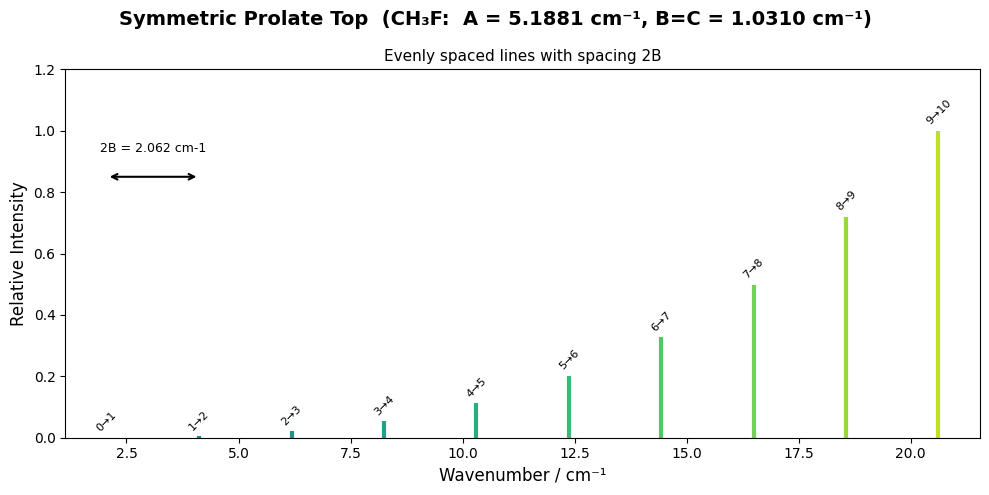

In [ ]:
# Plot the prolate symmetric top stick spectrum

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Symmetric Prolate Top  (CH₃F:  A = 5.1881 cm⁻¹, B=C = 1.0310 cm⁻¹)',
             fontsize=14, fontweight='bold')

# Colour-map: each transition gets a slightly different colour so they are
# visually distinguishable, progressing from blue-green to yellow.
colors_pro = plt.cm.viridis(np.linspace(0.4, 0.9, len(frequencies_prolate)))

# Draw a vertical line at each transition frequency.
# vlines(x, ymin, ymax) draws a vertical line from 0 to the intensity value.
for i in range(len(frequencies_prolate)):
    nu = frequencies_prolate[i]
    I  = intensities_prolate[i]
#for i, (nu, I) in enumerate(transitions_prolate):
    ax.vlines(nu, 0, I, color=colors_pro[i], linewidth=3)
    # Label each stick with the J → J+1 assignment, tilted 45° to avoid overlap.
    ax.text(nu, I + 0.02, f'{i}→{i+1}', ha='center', fontsize=8, rotation=45)

ax.set_xlabel('Wavenumber / cm⁻¹', fontsize=12)
ax.set_ylabel('Relative Intensity', fontsize=12)
ax.set_title('Evenly spaced lines with spacing 2B', fontsize=11)
ax.set_ylim(0, 1.2)
ax.axhline(0, color='k', linewidth=0.5)   # baseline

# Annotate the 2B spacing between the first two lines
# A double-headed arrow highlights that consecutive lines are separated by 2B.
nu0 = frequencies_prolate[0]
nu1 = frequencies_prolate[1]
ax.annotate("", xy=(nu1, 0.85), xytext=(nu0, 0.85),
            arrowprops=dict(arrowstyle="<->", color="black", lw=1.5))
ax.text((nu0 + nu1) / 2, 0.93, "2B = " + str(round(nu1 - nu0, 3)) + " cm-1",
        ha="center", fontsize=9)

plt.tight_layout()
plt.show()


---
## Part 3: Symmetric Oblate Top

For an **oblate symmetric top** ($I_A = I_B < I_C$, i.e., $A = B > C$), the energy levels are:

$$E(J, K) = hBJ(J+1) + h(C - B)K^2$$

Since $C < B$, the term $(C - B) < 0$, so **higher K levels have lower energy** — opposite to the prolate case.

**Transition frequencies** ($\Delta J = +1$, $\Delta K = 0$):
$$\tilde{\nu}(J \to J+1) = 2B(J+1)$$

The spectrum is again evenly spaced in $2B$, but the level ordering within each J is inverted.

In [ ]:
# Part 3 — Oblate Symmetric Top: NH₃

# Energy formula: E(J,K) = B·J(J+1) + (C−B)·K²
# (C−B) is negative for an oblate top, so levels with larger |K| sit LOWER in energy
# the opposite ordering to a prolate top.
# Despite this, the transition frequencies are the same: ν̃ = 2B(J+1),
# because the K-dependent term again cancels between upper and lower states.

# Rotational constants for NH₃ (cm⁻¹) - calculated above
B_oblate = 9.9745   # A = B for oblate
C_oblate = 6.3423

frequencies_oblate  = []
intensities_oblate  = []

for J in range(J_max):

    # Same transition frequency formula as prolate: nu = 2B(J+1)
    nu = 2 * B_oblate * (J + 1)

    total_intensity = 0
    for K in range(0, J + 1):

        # Energy of lower level
        # (C-B) is negative for oblate, so high-K levels sit lower in energy
        E_lower = h*B_oblate * J * (J + 1) + h*(C_oblate - B_oblate) * K**2

        if K == 0:
            g_K = 1
        else:
            g_K = 2
        g_M = 2 * J + 1
        g   = g_K * g_M

        boltzmann    = g * np.exp(-E_lower / (kB_hc * T))
        line_strength = J + 1

        total_intensity += boltzmann * line_strength

    frequencies_oblate.append(nu)
    intensities_oblate.append(total_intensity)

    #Normalize
max_intensity = max(intensities_oblate)
for i in range(len(intensities_oblate)):
  intensities_oblate[i] = intensities_oblate[i] / max_intensity


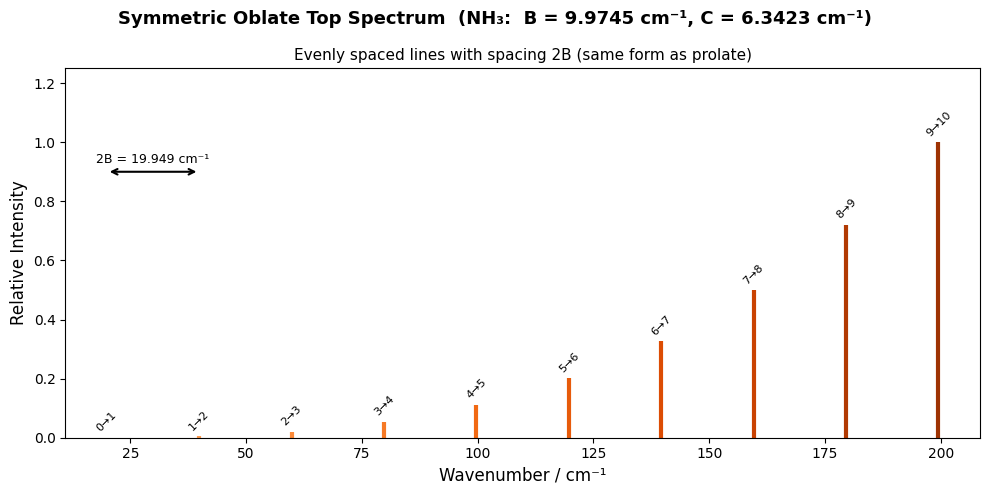

In [ ]:
# Plot the oblate symmetric top stick spectrum

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle('Symmetric Oblate Top Spectrum  (NH₃:  B = 9.9745 cm⁻¹, C = 6.3423 cm⁻¹)',
             fontsize=13, fontweight='bold')

# Orange colour-map to visually distinguish this spectrum from the prolate one
colors_obl = plt.cm.Oranges(np.linspace(0.4, 0.9, len(frequencies_oblate)))

for i in range(len(frequencies_oblate)):
    nu = frequencies_oblate[i]
    I  = intensities_oblate[i]
    ax.vlines(nu, 0, I, color=colors_obl[i], linewidth=3)
    ax.text(nu, I + 0.02, f'{i}→{i+1}', ha='center', fontsize=8, rotation=45)

ax.set_xlabel('Wavenumber / cm⁻¹', fontsize=12)
ax.set_ylabel('Relative Intensity', fontsize=12)
ax.set_title('Evenly spaced lines with spacing 2B (same form as prolate)', fontsize=11)
ax.set_ylim(0, 1.25)
ax.axhline(0, color='k', linewidth=0.5)

# Annotate spacing — confirm lines are separated by 2B as expected
nu0 = frequencies_oblate[0]
nu1 = frequencies_oblate[1]
ax.annotate('', xy=(nu1, 0.9), xytext=(nu0, 0.9),
             arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
ax.text((nu0 + nu1) / 2, 0.93, f'2B = {nu1 - nu0:.3f} cm⁻¹', ha='center', fontsize=9)

plt.tight_layout()
plt.show()
